# 01 · Construction archetypes

I cluster dwellings by construction characteristics within each dwelling type, then combine their construction group with a heating-system family.


In [ ]:
# Review copy: read saved results without running the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("Review copy: source inputs and third-party engines are excluded. Read saved results or use the Streamlit app.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()
print(f"EnerMap - {STUDY_AREA}   |   cores: {N_JOBS}")

EnerMap - Guildford   |   cores: 32


In [2]:
table = pd.read_parquet(TABLE_NUMERIC)
labels = pd.read_parquet(TABLE_LABELS)
df = labels.join(table.drop(columns=[c for c in table.columns if c in labels.columns]))
df["is_flat_roof"] = df["is_flat_roof"].astype(bool)
strata_counts = df[STRATA_COL].value_counts()
print("strata (built form):"); print(strata_counts.to_string())
print(f"\nconstruction theme : {CONSTRUCTION_CAT} + {CONSTRUCTION_NUM}")
print(f"known attributes   : {KNOWN_CAT} + {KNOWN_NUM}   (assignability diagnostic only)")
print(f"selection          : K-Means & GMM-diag, k={K_RANGE_STRATUM}, min cluster {MIN_CLUSTER_SIZE}, stability >= {STABILITY_MIN}")

strata (built form):
accommodation_type
Detached             18699
Semi-detached        18243
Flat                 11621
Terraced              8175
Caravan or mobile      461
Unknown                101

construction theme : ['wall_construction_resolved', 'wall_insulation', 'glazing_type', 'roof_type'] + ['age_band_ord', 'wall_U', 'roof_U', 'window_U']
known attributes   : ['built_form', 'tenure', 'is_flat_roof'] + ['age_band_ord', 'floor_area_final', 'storeys_est', 'height_eaves_m', 'area_m2', 'uprn_count']   (assignability diagnostic only)
selection          : K-Means & GMM-diag, k=(2, 12), min cluster 300, stability >= 0.8


## 1 · Construction sub-archetypes, one scan per stratum

Per stratum: design matrix (one-hot categoricals + winsorised, standardised numerics), then for every k both
algorithms are fitted and scored — SSD, BIC, silhouette, smallest cluster, bootstrap stability and
assignability — in parallel on all cores. The selection keeps the largest k that passes the size and stability
gates.

Detached          : 18,699 dwellings, k scanned (2, 12), 26 encoded features, 36 s  ->  gmm k=9


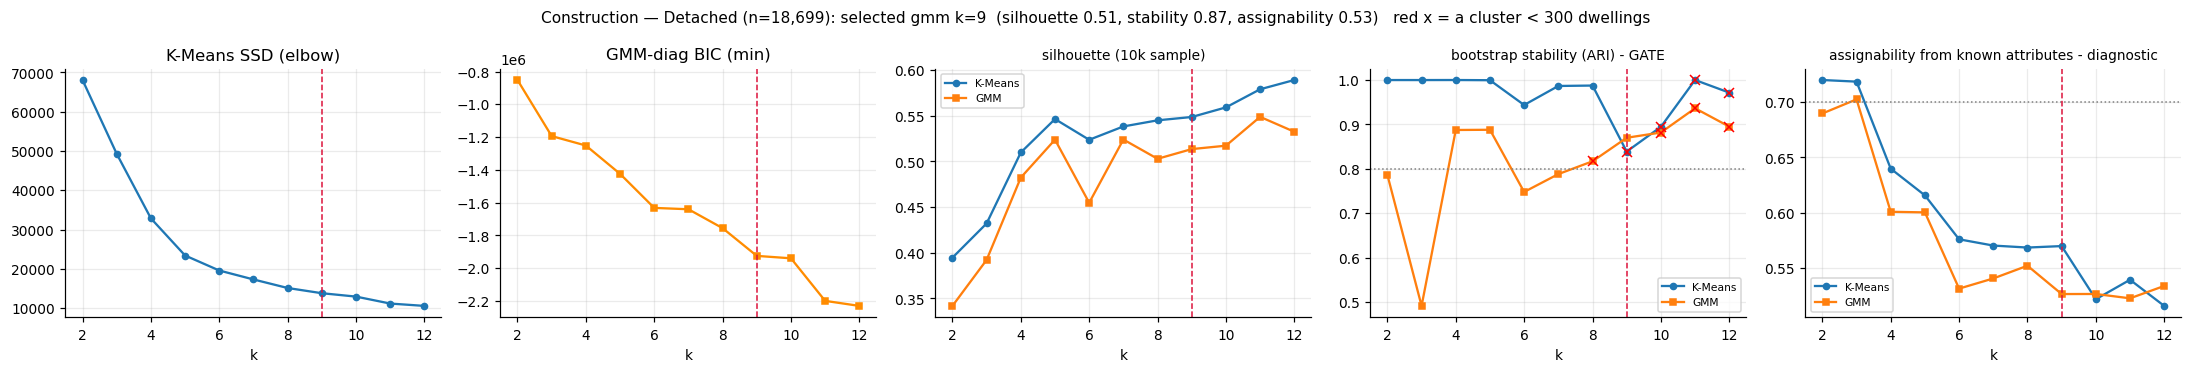

Semi-detached     : 18,243 dwellings, k scanned (2, 12), 26 encoded features, 29 s  ->  gmm k=11


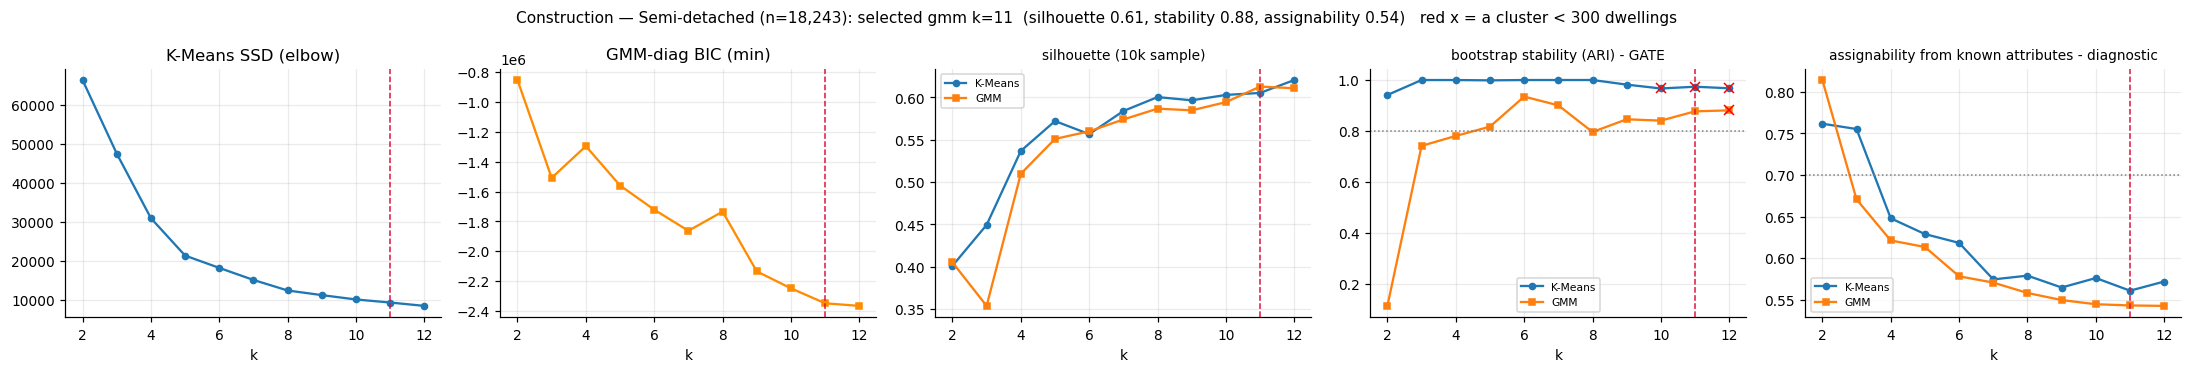

Terraced          :  8,175 dwellings, k scanned (2, 12), 25 encoded features, 14 s  ->  kmeans k=4


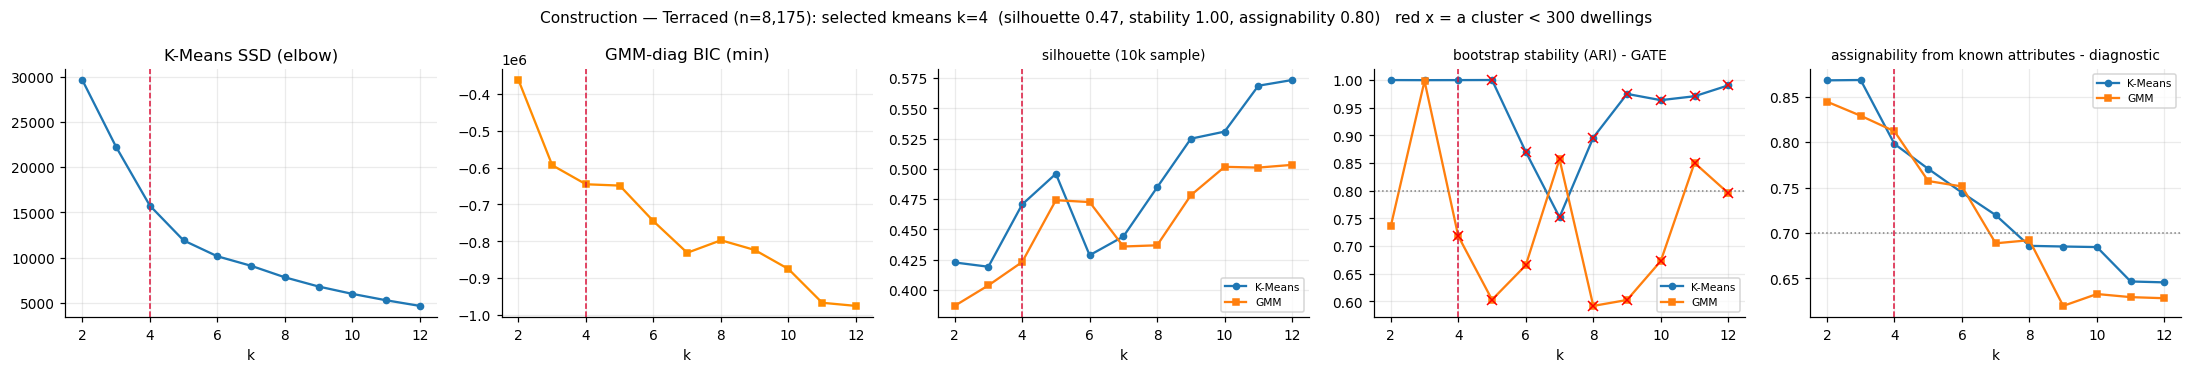

Flat              : 11,621 dwellings, k scanned (2, 12), 26 encoded features, 23 s  ->  kmeans k=8


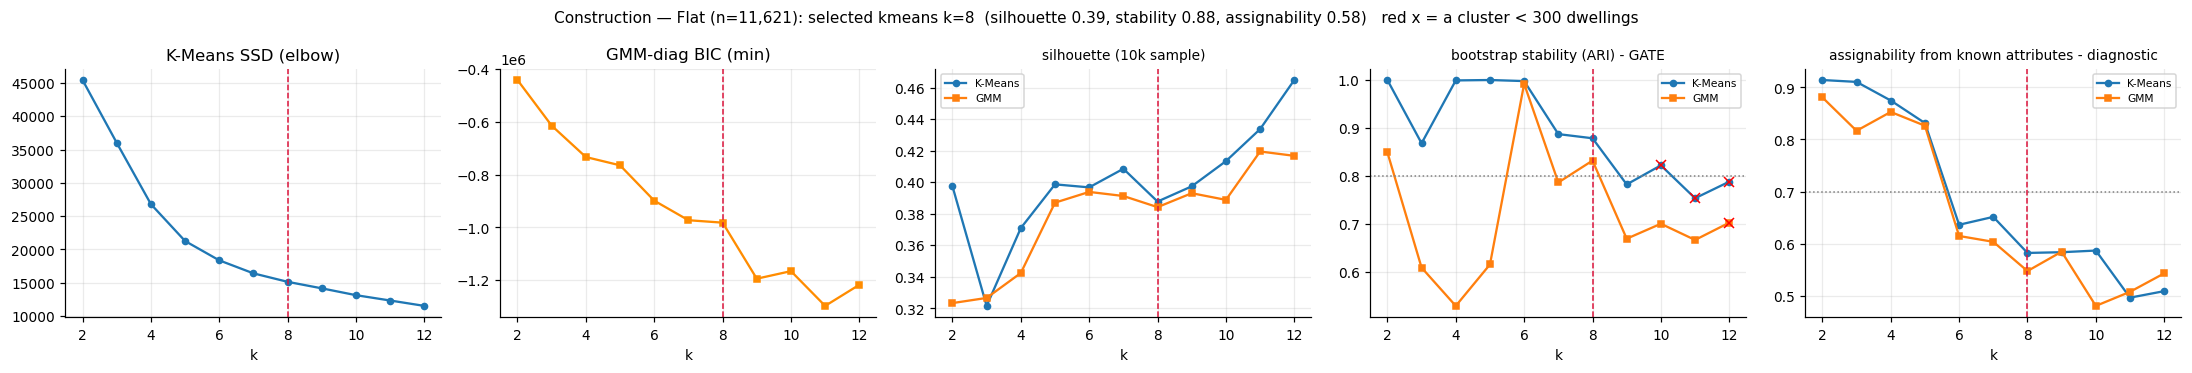

Caravan or mobile :    461 dwellings -> single sub-archetype C.Park.1
Unknown           :    101 dwellings -> single sub-archetype C.Unk.1


In [3]:
construction = pd.Series(index=df.index, dtype="object")
criteria_all, selections, fitted = {}, {}, {}
order = STRATA + [s for s in strata_counts.index if s not in STRATA]
for stratum in order:
    sub_df = df[df[STRATA_COL] == stratum]
    prefix = f"C.{STRATA_ABBREV.get(stratum, 'X')}."
    if stratum not in STRATA or len(sub_df) < MIN_STRATUM_OBS:
        construction.loc[sub_df.index] = prefix + "1"
        selections[stratum] = {"algo": "single", "k": 1, "n": len(sub_df)}
        print(f"{stratum:18s}: {len(sub_df):>6,} dwellings -> single sub-archetype {prefix}1")
        continue
    enc = H.FeatureEncoder(CONSTRUCTION_CAT, CONSTRUCTION_NUM, CONSTRUCTION_LOG); X = enc.fit_transform(sub_df)
    kenc = H.FeatureEncoder(KNOWN_CAT, KNOWN_NUM, KNOWN_LOG); KX = kenc.fit_transform(sub_df)
    kr = (K_RANGE_STRATUM[0], max(K_RANGE_STRATUM[0], min(K_RANGE_STRATUM[1], len(sub_df) // MIN_CLUSTER_SIZE)))
    t0 = time.time()
    crit, store, mstore = H.scan_stratum(X, KX, k_range=kr, seed=SEED, n_jobs=N_JOBS, cap=SILHOUETTE_CAP, n_boot=STABILITY_BOOT, frac=STABILITY_FRAC)
    if stratum in K_OVERRIDES:
        algo, k = K_OVERRIDES[stratum]
        row = crit[(crit.algo == algo) & (crit.k == k)].iloc[0]
        sel = {"algo": algo, "k": int(k), "silhouette": row["silhouette"], "stability": row["stability"], "pred_acc": row["pred_acc"],
               "min_cluster": int(row["min_cluster"]), "gate_relaxed": False, "candidates": "override"}
    else:
        sel = H.select_clustering(crit, MIN_CLUSTER_SIZE, STABILITY_MIN)
    raw = store[(sel["algo"], sel["k"])]
    remap = {old: i + 1 for i, old in enumerate(pd.Series(raw).value_counts().index)}   # 1..k by size
    construction.loc[sub_df.index] = [f"{prefix}{remap[l]}" for l in raw]
    sel["n"] = len(sub_df); sel["features"] = enc.feature_names
    selections[stratum] = sel; criteria_all[stratum] = crit
    fitted[stratum] = {"encoder": enc, "model": mstore[(sel["algo"], sel["k"])], "remap": remap, "prefix": prefix, "algo": sel["algo"]}
    crit.to_csv(CLUSTERS_DIR / f"criteria_construction_{STRATA_ABBREV[stratum]}.csv", index=False)
    print(f"{stratum:18s}: {len(sub_df):>6,} dwellings, k scanned {kr}, {len(enc.feature_names)} encoded features, {time.time()-t0:.0f} s  ->  {sel['algo']} k={sel['k']}")
    H.plot_criteria(crit, sel, f"Construction — {stratum} (n={len(sub_df):,})", MIN_CLUSTER_SIZE, STABILITY_MIN, PRED_ACC_REF,
                    save=FIG / f"01_criteria_construction_{STRATA_ABBREV[stratum]}.png")

In [4]:
sel_table = pd.DataFrame({s: {k: v for k, v in d.items() if k not in ("candidates", "features")} for s, d in selections.items()}).T
sel_table.to_csv(CLUSTERS_DIR / "selection_construction.csv")
print(f"construction sub-archetypes: {construction.nunique()}")
sel_table

construction sub-archetypes: 34


,algo,k,silhouette,stability,pred_acc,min_cluster,gate_relaxed,n
Detached,gmm,9,0.513465,0.869905,0.5262,414,False,18699
Semi-detached,gmm,11,0.612833,0.877063,0.5434,509,False,18243
Terraced,kmeans,4,0.470597,0.999841,0.798165,670,False,8175
Flat,kmeans,8,0.387714,0.87844,0.582307,537,False,11621
Caravan or mobile,single,1,NaN,NaN,NaN,NaN,NaN,461
Unknown,single,1,NaN,NaN,NaN,NaN,NaN,101


**Reading the criteria.** SSD and BIC fall monotonically on one-hot dominated data, so the elbow is weak; the
informative curves are stability (does the split reproduce under resampling?) and the smallest-cluster count.
Assignability from no-certificate attributes says how well an authority *without* certificates could infer
the envelope class from form, age, size and tenure.

## 2 · Systems families

With one systems attribute available for every dwelling, the sub-archetypes are its classes. Their generator
efficiencies come from `parameters/heating_systems/efficiencies.json`.

In [5]:
from ukubem import params as PRM
systems = "S." + df["heat_system"].map(SYSTEMS_FAMILY).fillna("GasBoiler")
fam = pd.crosstab(df[STRATA_COL], systems); fam.loc["TOTAL"] = fam.sum()
eff = PRM.load("heating_systems", "efficiencies")
sys_json = {}
for fam_name, n in systems.value_counts().items():
    key = fam_name.replace("S.", "")
    d = {"n": int(n), "share": round(n / len(df), 4),
         "typology_shares": (df.loc[systems == fam_name, STRATA_COL].value_counts(normalize=True).round(3)).to_dict(),
         "heat_system_classes": sorted(df.loc[systems == fam_name, "heat_system"].unique().tolist())}
    kind = eff["family_fuel"][fam_name]["kind"]
    if kind == "boiler":
        d["generator"] = {"type": "combustion boiler", "fuel": eff["family_fuel"][fam_name]["fuel"], "efficiency": eff["boiler_eff"]}
    elif kind == "heat_pump":
        d["generator"] = {"type": "air-source heat pump", "SPF_space": eff["hp_scop"], "SPF_dhw": eff["dhw_hp_scop"]}
    else:
        d["generator"] = {"type": "direct electric", "efficiency": eff["direct_eff"]}
    sys_json[fam_name] = d
json.dump(H.json_safe(sys_json), open(CLUSTERS_DIR / "subarchetypes_systems.json", "w"), indent=2)
print(f"systems families: {systems.nunique()}")
fam

systems families: 8


heat_system,S.ElecResistive,S.ElecStorage,S.GasBoiler,S.GasCommunal,S.HeatPump,S.LPGBoiler,S.OilBoiler,S.SolidFuel
accommodation_type,,,,,,,,
Caravan or mobile,7,6,242,0,8,155,32,11
Detached,182,164,16524,17,709,254,816,33
Flat,1489,1447,7232,1146,258,21,23,5
Semi-detached,221,273,17035,18,248,113,299,36
Terraced,217,230,7558,14,71,33,41,11
Unknown,0,0,96,0,5,0,0,0
TOTAL,2116,2120,48687,1195,1299,576,1211,96


## 3 · Combine: construction × systems

In [6]:
archetype = construction + " × " + systems
combo = archetype.value_counts(); big = combo[combo >= 100]
print(f"possible combinations : {construction.nunique() * systems.nunique()}")
print(f"occurring             : {len(combo)}")
print(f"with >= 100 dwellings : {len(big)}  covering {100 * big.sum() / len(df):.1f} % of the stock")
print(f"with >= 30  dwellings : {(combo >= 30).sum()}  covering {100 * combo[combo >= 30].sum() / len(df):.1f} %")
print("(every dwelling is simulated with its own geometry, so rare combinations are not a problem for deployment)")
combo.head(15)

possible combinations : 272
occurring             : 250
with >= 100 dwellings : 59  covering 94.1 % of the stock
with >= 30  dwellings : 100  covering 97.8 %
(every dwelling is simulated with its own geometry, so rare combinations are not a problem for deployment)


C.Semi.1 × S.GasBoiler    5296
C.Det.1 × S.GasBoiler     4658
C.Ter.1 × S.GasBoiler     4069
C.Det.2 × S.GasBoiler     3339
C.Det.3 × S.GasBoiler     3057
C.Semi.2 × S.GasBoiler    3003
C.Semi.3 × S.GasBoiler    2010
C.Ter.2 × S.GasBoiler     1673
C.Det.4 × S.GasBoiler     1632
C.Semi.4 × S.GasBoiler    1520
C.Flat.1 × S.GasBoiler    1513
C.Semi.5 × S.GasBoiler    1336
C.Flat.2 × S.GasBoiler    1258
C.Ter.3 × S.GasBoiler     1177
C.Det.6 × S.GasBoiler     1123
Name: count, dtype: int64

## 4 · Characterisation (modal categories, median + p5–p95 feasible ranges)

In [7]:
char = H.characterise(df, construction, CONSTRUCTION_CAT + ["age_band_resolved"], CONSTRUCTION_NUM)
names = H.dedupe_names({lab: H.name_construction(r, AGE_BAND_LABEL) for lab, r in char.iterrows()})
char.insert(0, "name", pd.Series(names))
extra = df.groupby(construction).agg(synthesised_pct=("attributes_observed", lambda s: 100 * (1 - s.mean())),
                                     certificate_kWh_m2_median=("EPh_sap", "median"), floor_area_median=("floor_area_final", "median"))
char = char.join(extra)
char.to_csv(CLUSTERS_DIR / "characterisation_construction.csv")
json.dump(H.characterisation_json(char, CONSTRUCTION_CAT + ["age_band_resolved"], CONSTRUCTION_NUM, names),
          open(CLUSTERS_DIR / "subarchetypes_construction.json", "w"), indent=2)
show = ["name", "n", "share", "synthesised_pct", "wall_construction_resolved__share", "wall_insulation__share", "glazing_type__share",
        "roof_type__share", "wall_U__median", "wall_U__p5", "wall_U__p95", "window_U__median", "roof_U__median", "certificate_kWh_m2_median"]
char[show].round(2)

,name,n,share,synthesised_pct,wall_construction_resolved__share,wall_insulation__share,glazing_type__share,roof_type__share,wall_U__median,wall_U__p5,wall_U__p95,window_U__median,roof_U__median,certificate_kWh_m2_median
label,,,,,,,,,,,,,,
C.Det.1,"insulated cavity, double glazing, pitched insu...",5004,0.09,44.50,1.00,0.93,1.00,1.00,0.70,0.70,0.70,3.02,0.40,203.0
C.Det.2,"uninsulated cavity, double glazing, pitched in...",3570,0.06,41.29,1.00,1.00,0.96,0.99,1.50,1.50,1.50,3.02,0.40,249.0
C.Det.3,"insulated cavity, double glazing, pitched insu...",3440,0.06,43.58,0.84,0.99,1.00,0.94,0.35,0.30,0.45,3.02,0.26,178.0
C.Det.4,"insulated cavity, triple glazing, unknown roof...",2056,0.04,34.05,1.00,0.95,0.94,0.97,0.24,0.16,0.30,1.80,0.14,72.0
C.Det.5,"uninsulated solid brick, double glazing, pitch...",1423,0.02,41.67,0.86,1.00,0.90,0.98,1.70,1.50,1.70,3.02,0.40,254.0
C.Det.6,"insulated cavity, double glazing, pitched insu...",1322,0.02,50.45,0.68,0.82,0.74,0.43,0.70,0.30,0.72,3.02,1.50,214.0
C.Det.7,"uninsulated cavity, double glazing, pitched un...",803,0.01,41.97,1.00,1.00,0.96,0.80,1.50,1.50,1.50,3.02,2.30,271.0
C.Det.8,"uninsulated cavity, single glazing, pitched in...",667,0.01,38.23,0.57,0.76,1.00,0.75,1.50,0.40,1.70,5.72,0.40,294.0
C.Det.9,"uninsulated solid brick, double glazing, pitch...",414,0.01,37.44,0.88,1.00,0.87,0.81,1.70,1.50,1.90,3.02,2.30,298.0


## 5 · Checks: purity for measures, and the spread the archetypes leave to geometry and behaviour

The construction archetypes are built from fabric, so a retrofit measure means one thing inside each. The
within-archetype spread of the *certificate* energy intensity (an asset rating under standard occupancy,
certificated rows only) is reported as the part the fabric archetype does not explain: it comes from geometry
and adjacency (floor area, storeys, party walls, a dwelling above or an exposed roof) — which is why every
dwelling is simulated with its own geometry rather than one representative per archetype.

In [8]:
L = df.assign(construction_sa=construction.values, systems_fam=systems.values, archetype=archetype.values)
rows = []
for name, col in [("construction sub-archetypes", "construction_sa"), ("construction × systems", "archetype")]:
    sizes = L[col].value_counts(); w = sizes / sizes.sum()
    cv = L.groupby(col)["EPh_sap"].agg(lambda s: s.std() / s.mean())
    rows.append({"partition": name, "groups": len(sizes), "groups>=300": int((sizes >= 300).sum()),
                 "within-group CV of certificate kWh/m2 (certificated rows)": round(float((cv * w).sum()), 3),
                 **{f"purity {c}": round(float((H.purity(L, col, c) * w).sum()), 3) for c in ["wall_construction_resolved", "wall_insulation", "glazing_type", "heat_system"]}})
pd.DataFrame(rows).set_index("partition")

,groups,groups>=300,within-group CV of certificate kWh/m2 (certificated rows),purity wall_construction_resolved,purity wall_insulation,purity glazing_type,purity heat_system
partition,,,,,,,
construction sub-archetypes,34,33,0.370,0.855,0.937,0.956,0.85
construction × systems,250,38,0.295,0.857,0.938,0.956,1.00


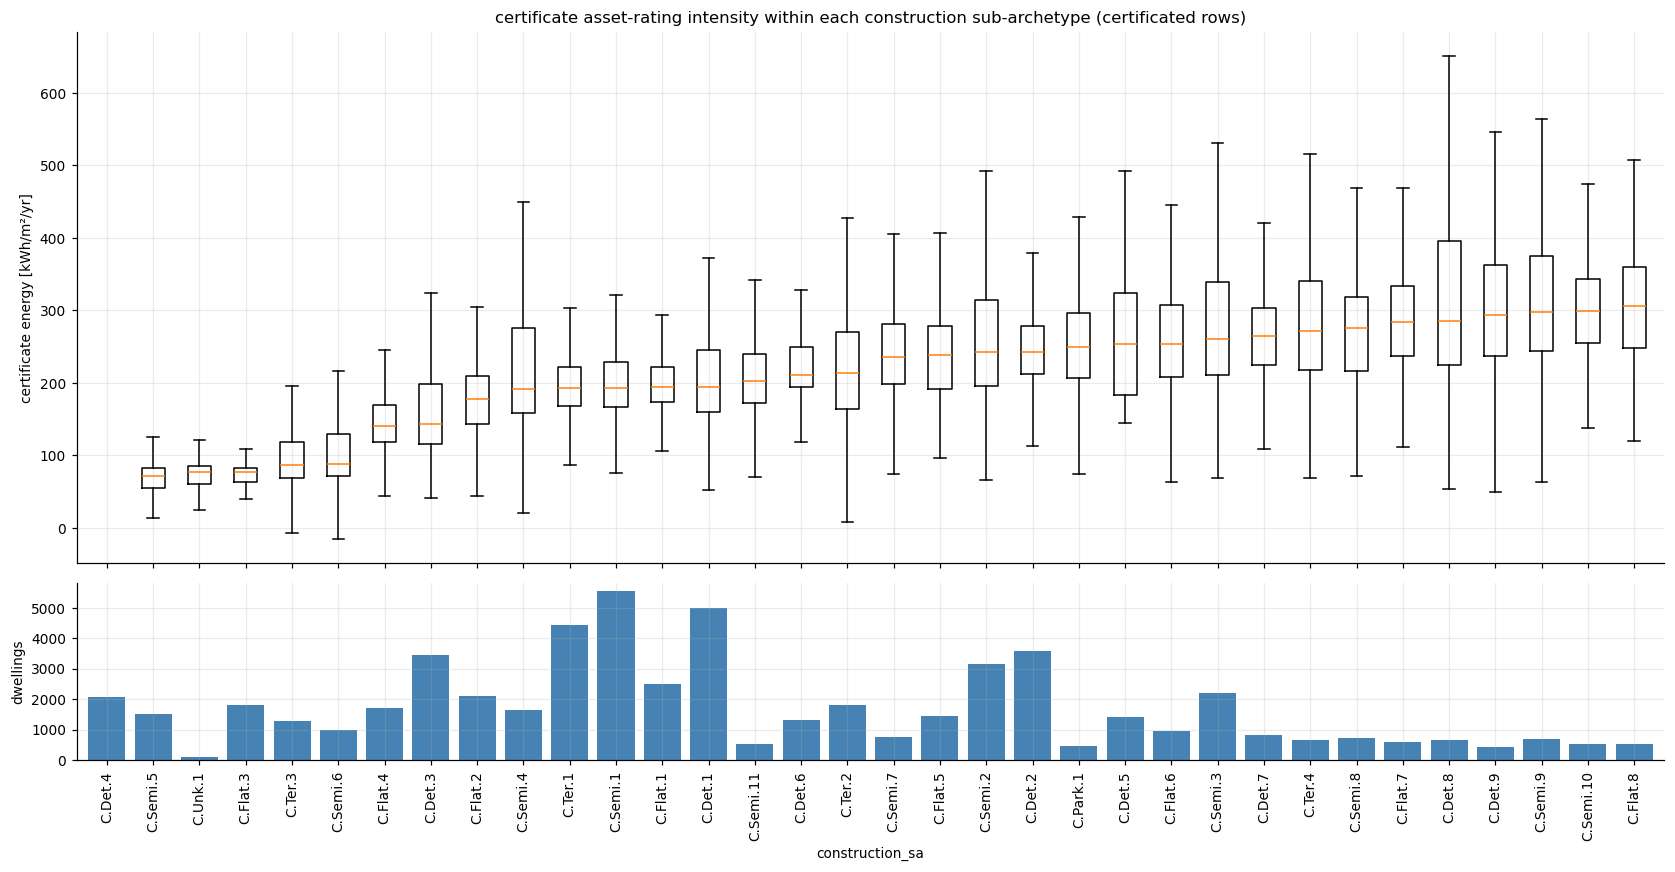

In [9]:
order_ = L.groupby("construction_sa")["EPh_sap"].median().sort_values().index
fig, axes = plt.subplots(2, 1, figsize=(max(10, 0.45 * len(order_)), 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
data = [L.loc[L["construction_sa"] == lab, "EPh_sap"].dropna().clip(upper=L["EPh_sap"].quantile(0.995)) for lab in order_]
axes[0].boxplot(data, tick_labels=order_, showfliers=False)
axes[0].set_ylabel("certificate energy [kWh/m²/yr]"); axes[0].set_title("certificate asset-rating intensity within each construction sub-archetype (certificated rows)")
L["construction_sa"].value_counts().reindex(order_).plot.bar(ax=axes[1], width=0.8, color="steelblue")
axes[1].set_ylabel("dwellings"); axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout(); fig.savefig(FIG / "01_intensity_by_construction_sa.png", bbox_inches="tight"); plt.show()

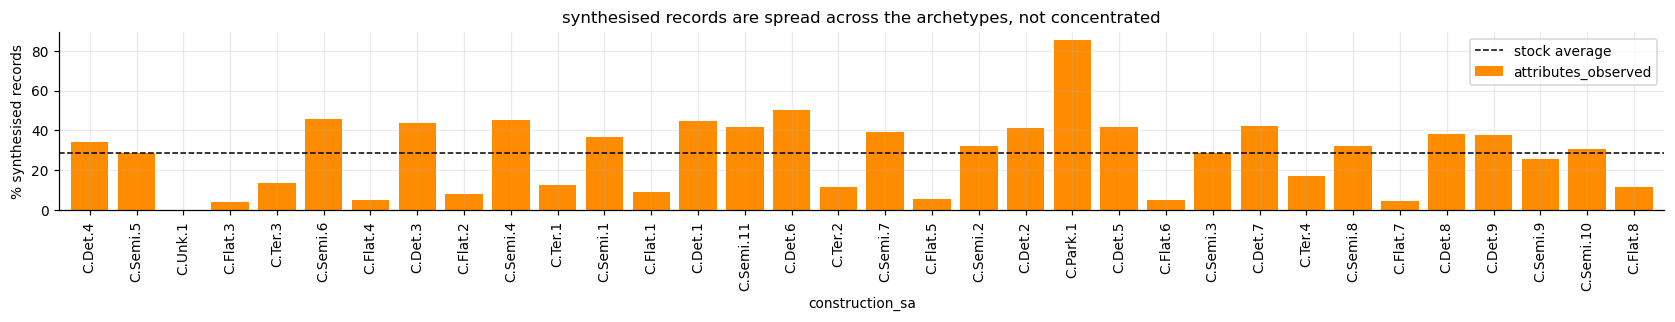

In [10]:
syn = L.groupby("construction_sa")["attributes_observed"].agg(lambda s: 100 * (1 - s.mean())).reindex(order_)
fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(order_)), 3))
syn.plot.bar(ax=ax, width=0.8, color="darkorange"); ax.axhline(100 * (1 - L["attributes_observed"].mean()), color="k", ls="--", lw=1, label="stock average")
ax.set_ylabel("% synthesised records"); ax.legend(); ax.tick_params(axis="x", rotation=90); ax.set_title("synthesised records are spread across the archetypes, not concentrated")
plt.tight_layout(); fig.savefig(FIG / "01_synthesised_share_by_construction_sa.png", bbox_inches="tight"); plt.show()

## 6 · Save the partition

`cluster` (integer) = construction sub-archetype; `systems_fam` and `archetype` (construction × systems) ride along.

In [11]:
import joblib
lookup = (L.groupby("construction_sa").agg(n=("floor_area_final", "size"), stratum=(STRATA_COL, H.mode_or_none))
            .join(pd.Series(names, name="name")).reset_index())
lookup.insert(0, "cluster", range(len(lookup)))
lookup.to_csv(ARCHETYPE_LOOKUP, index=False)
cid = lookup.set_index("construction_sa")["cluster"]
dwc = table.copy(); dwc["cluster"] = L["construction_sa"].map(cid).astype(int).values
dwc.to_parquet(CLUSTERS_DIR / "data_with_clusters.parquet")
L[["UPRN", "LSOA", "construction_sa", "systems_fam", "archetype"]].assign(cluster=dwc["cluster"]).to_csv(CLUSTERS_DIR / "cluster_labels.csv")
joblib.dump({"partition": "stratified", "strata": fitted, "cat": CONSTRUCTION_CAT, "num": CONSTRUCTION_NUM, "log": CONSTRUCTION_LOG, "lookup": cid.to_dict()},
            CLUSTERS_DIR / "clustering_model.pkl")
json.dump(H.json_safe({s: {k: v for k, v in d.items() if k != "candidates"} for s, d in selections.items()}), open(CLUSTERS_DIR / "selections.json", "w"), indent=2)
print(f"{len(lookup)} construction sub-archetypes -> outputs/{CLUSTERS_DIR.name}/")
lookup

34 construction sub-archetypes -> outputs/archetypes/


,cluster,construction_sa,n,stratum,name
0,0,C.Det.1,5004,Detached,"insulated cavity, double glazing, pitched insu..."
1,1,C.Det.2,3570,Detached,"uninsulated cavity, double glazing, pitched in..."
2,2,C.Det.3,3440,Detached,"insulated cavity, double glazing, pitched insu..."
3,3,C.Det.4,2056,Detached,"insulated cavity, triple glazing, unknown roof..."
4,4,C.Det.5,1423,Detached,"uninsulated solid brick, double glazing, pitch..."
5,5,C.Det.6,1322,Detached,"insulated cavity, double glazing, pitched insu..."
6,6,C.Det.7,803,Detached,"uninsulated cavity, double glazing, pitched un..."
7,7,C.Det.8,667,Detached,"uninsulated cavity, single glazing, pitched in..."
8,8,C.Det.9,414,Detached,"uninsulated solid brick, double glazing, pitch..."
9,9,C.Flat.1,2486,Flat,"insulated cavity, double glazing, dwelling abo..."


**Next:** `02_representatives.ipynb` — the per-dwelling engine inputs and the representatives of every sub-archetype.